## Imports

In [1]:
from sklearn.datasets import load_breast_cancer, load_wine
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import shap

## 1. Veri Setinin Yüklenmesi

In [2]:
data = load_wine()
feature_names = pd.DataFrame(data.data, columns=data.feature_names)
target = pd.Series(data.target, name='target')
df = pd.concat([feature_names, target], axis=1)
print(df.head())

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  target  
0          

In [3]:
print(df.nunique())

alcohol                         126
malic_acid                      133
ash                              79
alcalinity_of_ash                63
magnesium                        53
total_phenols                    97
flavanoids                      132
nonflavanoid_phenols             39
proanthocyanins                 101
color_intensity                 132
hue                              78
od280/od315_of_diluted_wines    122
proline                         121
target                            3
dtype: int64


Bu bölümde, scikit-learn kütüphanesinden 'Wine Classification' veri seti yüklenmiştir. Veri seti, 13 adet sayısal özellik ve üç farklı şarap sınıfını temsil eden bir hedef değişkenden oluşmaktadır. Veriler pandas DataFrame formatına dönüştürülmüş ve verinin genel yapısını kontrol etmek için ilk 5 satır incelenmiştir.

## 2. Veri Seti Kalite Kontrolleri

In [4]:
# Missing Value Analysis
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

Yapılan df.info() incelemesi sonucunda, veri setindeki 178 satırın tamamının dolu olduğu (non-null) görülmüştür. Hiçbir sütunda eksik değer bulunmadığı için herhangi bir doldurma (mean/median imputer) işlemi yapılmasına gerek duyulmamıştır.

In [5]:
# Outlier Analysis
# IQR
Q1 = feature_names.quantile(0.25)
Q3 = feature_names.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = ((feature_names < lower_bound) | (feature_names > upper_bound)).sum()
print(outliers[outliers > 0])

malic_acid           3
ash                  3
alcalinity_of_ash    4
magnesium            4
proanthocyanins      2
color_intensity      4
hue                  1
dtype: int64


IQR yöntemi kullanılarak yapılan analizde; malic_acid, ash, magnesium, color_intensity gibi birçok değişkende aykırı değerler tespit edilmiştir.

Aykırı değerlerin farklı aşamalarda bulunması, çeşitli sorunlara yol açar:

Eğitim Aşaması: Eğitim verilerindeki aykırı değerler, 'sınıflandırmada gereksiz yere karmaşık karar sınırlarına veya regresyon modellerinde gereksiz doğrusal olmama durumuna' neden olarak modelin genellenebilirliğini azaltabilir.

Değerlendirme Aşaması: Doğrulama veya test verilerinde aykırı değerler ortaya çıktığında, modellerin başa çıkmak üzere tasarlanmadıkları uç değerlerde kötü performans göstermelerine yol açarak 'model seçim sürecini güvenilmez hale getirebilirler'.

Üretim Aşaması: Modeller, gerçek dünya dağıtımında aykırı değerlerle karşılaştıklarında düşük güven düzeyi raporlayabilir veya zayıf tahminler yapabilir; bu da kritik uygulamalarda hatalı kararlara yol açma potansiyeli taşır.

In [6]:
# dtype information
df.dtypes

,0
alcohol,float64
malic_acid,float64
ash,float64
alcalinity_of_ash,float64
magnesium,float64
total_phenols,float64
flavanoids,float64
nonflavanoid_phenols,float64
proanthocyanins,float64
color_intensity,float64


Bu veri setindeki tüm özellikler sayısal (float64) türündedir ve hedef değişken tamsayı (int64) türündedir. Kategorik özellik bulunmamaktadır.

## 3. Keşifsel Veri Analizi (EDA)

In [7]:
# Statistical Properties
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


Veri setinin tanımlayıcı istatistikleri incelendiğinde, özelliklerin çok farklı ölçeklerde olduğu görülmektedir. Örneğin, proline değişkeni 278 ile 1680 arasında değerler alırken, nonflavanoid_phenols 0.13 ile 0.66 arasında değişmektedir. Bu durum, mesafe tabanlı algoritmaların (PCA, LDA, Lojistik Regresyon) hatalı ağırlıklandırma yapmaması için standartlaştırma işleminin zorunlu olduğunu kanıtlamaktadır.

flavanoids                    total_phenols                   0.864564
total_phenols                 flavanoids                      0.864564
od280/od315_of_diluted_wines  flavanoids                      0.787194
flavanoids                    od280/od315_of_diluted_wines    0.787194
od280/od315_of_diluted_wines  total_phenols                   0.699949
total_phenols                 od280/od315_of_diluted_wines    0.699949
dtype: float64


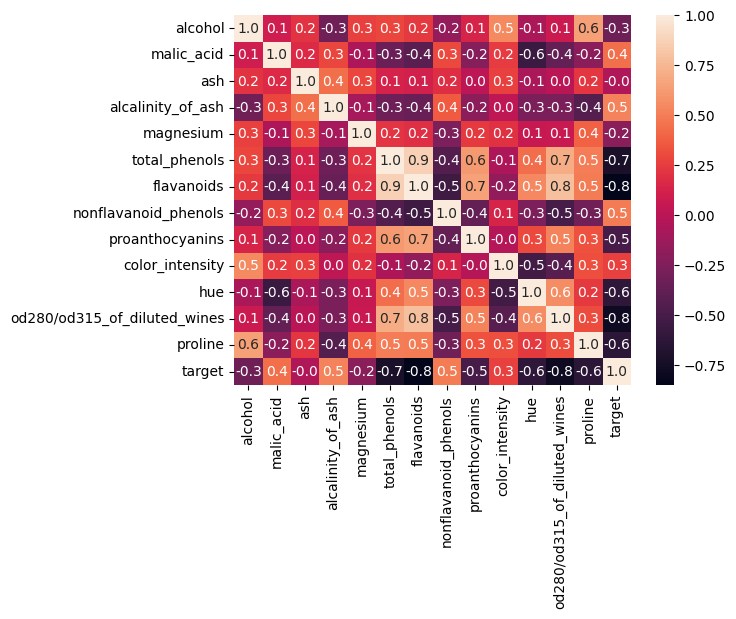

In [8]:
# Correlation Matrix
sns.heatmap(df.corr(), annot=True, fmt='.1f')

corr_pairs = df.corr().unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1]
print(corr_pairs.head(6))

Korelasyon matrisi ve ısı haritası incelendiğinde, en yüksek pozitif korelasyona sahip 3 çift şöyledir:
* Flavanoids & Total Phenols (0.86): Bu iki özellik arasında çok güçlü bir doğrusal ilişki vardır.
* Flavanoids & OD280/OD315 (0.79): Şarabın seyreltilme oranı ile flavanoid içeriği yüksek ilişkilidir.
* Total Phenols & OD280/OD315 (0.70): Toplam fenoller ile seyreltilme oranı arasında güçlü bir bağ vardır.

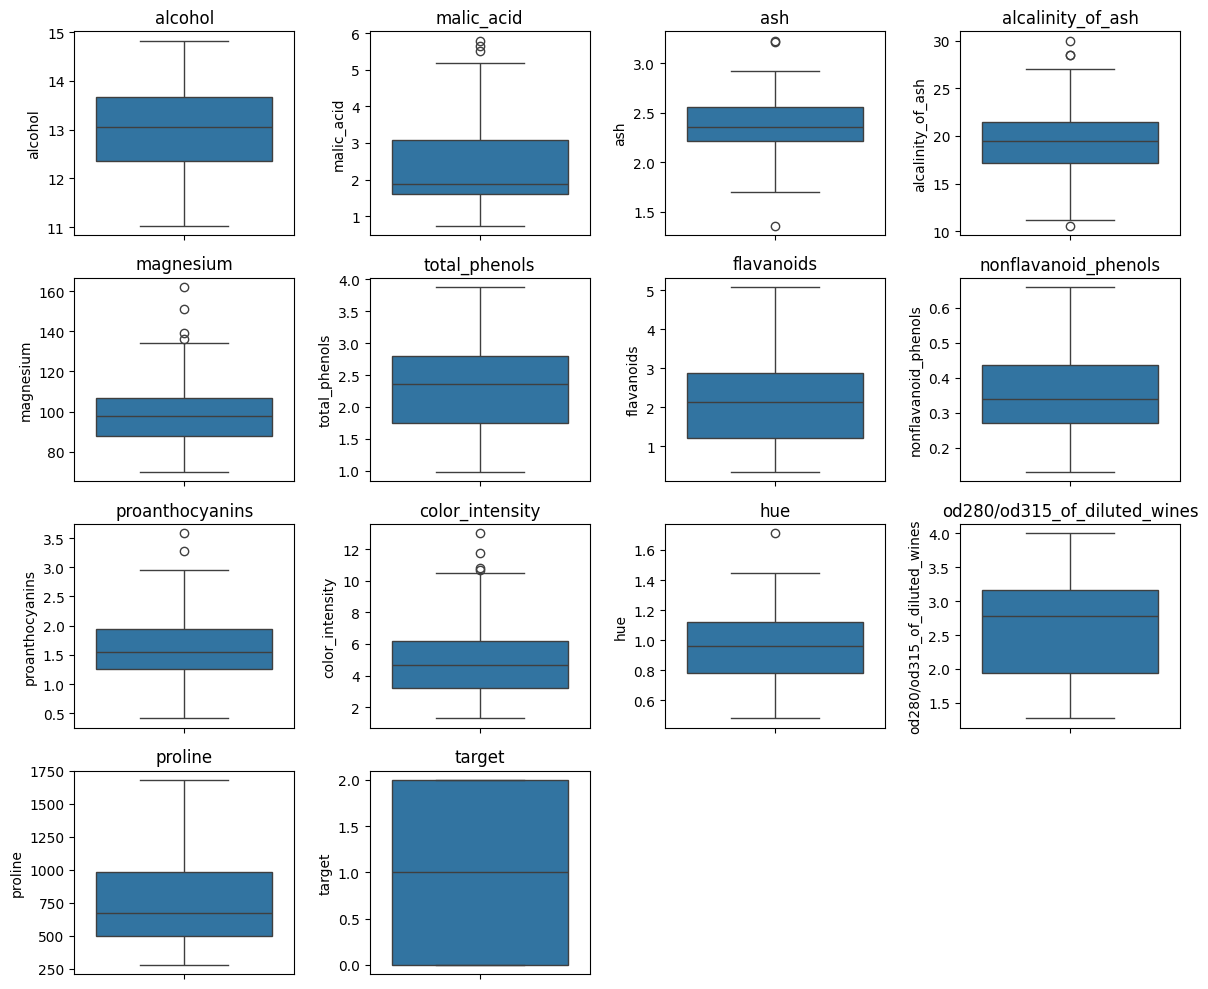

In [9]:
# Boxplot Analysis
plt.figure(figsize=(12, 10))
for i, col in enumerate(df.columns):
    plt.subplot(4, 4, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Her özellik için çizilen boxplot grafikleri, veri setindeki dağılımı ve aykırı değer eğilimlerini net bir şekilde göstermektedir. Özellikle malic_acid, magnesium, proanthocyanins ve color_intensity değişkenlerinde üst sınırın dışında kalan (outlier) değerler mevcuttur. Bu aykırı değerlerin varlığı, veriyi medyan ve çeyreklikler üzerinden ölçeklendiren RobustScaler yönteminin kullanılmasını desteklemektedir.


## 4. Veri Ölçeklendirme (Scaling) ve 5. Veri Setinin Bölünmesi ve 6. Özellik Seçimi ve Boyut İndirgeme

In [10]:
# Splitting the Dataset
X_train_full, X_test, y_train_full, y_test = train_test_split(feature_names, target, test_size=0.20, random_state=42, stratify=target)

X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.125, random_state=42, stratify=y_train_full)

# Data Scaling
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
X_scaled = scaler.transform(feature_names)

# Feature Selection and Dimensionality Reduction

# Principal Component Analysis
pca_temp = PCA().fit(X_train_scaled)
avg_var = 1.0 / len(pca_temp.explained_variance_ratio_)
# components whose variance ratio is greater than the mean
n_comp_pca = np.sum(pca_temp.explained_variance_ratio_ > avg_var)

pca = PCA(n_components=n_comp_pca)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Linear Discriminant Analysis
n_lda = min(len(np.unique(y_train)) - 1, 3)
lda = LDA(n_components=n_lda)
X_train_lda = lda.fit_transform(X_train_scaled, y_train)
X_val_lda = lda.transform(X_val_scaled)
X_test_lda = lda.transform(X_test_scaled)

print(f"Original features: {feature_names.shape[1]}")
print(f"After PCA: {X_train_pca.shape[1]}")
print(f"After LDA: {X_train_lda.shape[1]}")

Original features: 13
After PCA: 4
After LDA: 2


Bu çalışmada veri sızıntısını (Data Leakage) önlemek amacıyla önce train_test_split ile veri seti %70 Eğitim, %10 Validasyon ve %20 Test olarak bölünmüştür. Ölçeklendirme işlemi (RobustScaler), yalnızca eğitim seti üzerinden öğrenilmiş (fit) ve ardından tüm setlere uygulanmıştır. RobustScaler tercih edilmesinin nedeni, EDA bölümünde tespit edilen aykırı değerlerin (outliers) model üzerindeki etkisini minimize etmektir. Bu sayede tüm özellikler birbiriyle kıyaslanabilir düzeye getirilmiş, ancak aykırı değerlerin yapısı korunmuştur.

Boyut indirgeme aşamasında iki farklı yöntem uygulanmıştır:
* PCA: 'Açıklanan varyans oranı ortalamasından büyük olan' bileşenleri seçme kuralına göre 13 özellikten 4 ana bileşene inilmiştir.
* LDA: Sınıf etiketlerini kullanan denetimli bir yöntem olarak uygulanmış ve sınıf sayısı kısıtı nedeniyle 2 bileşene inilmiştir.

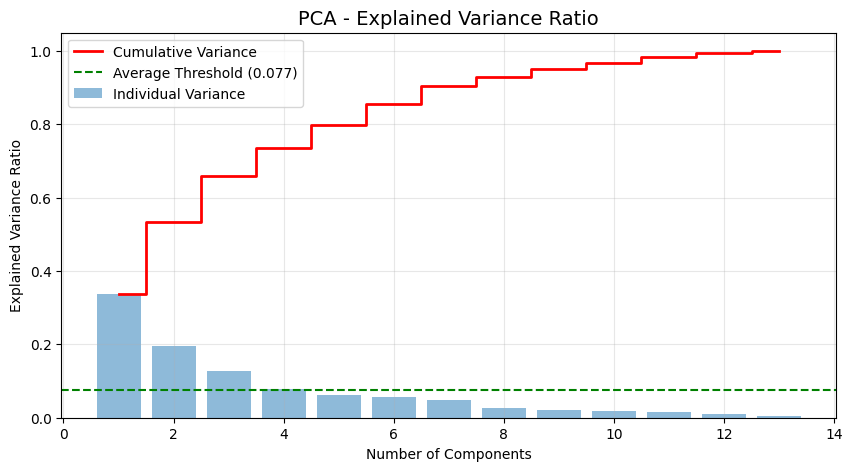

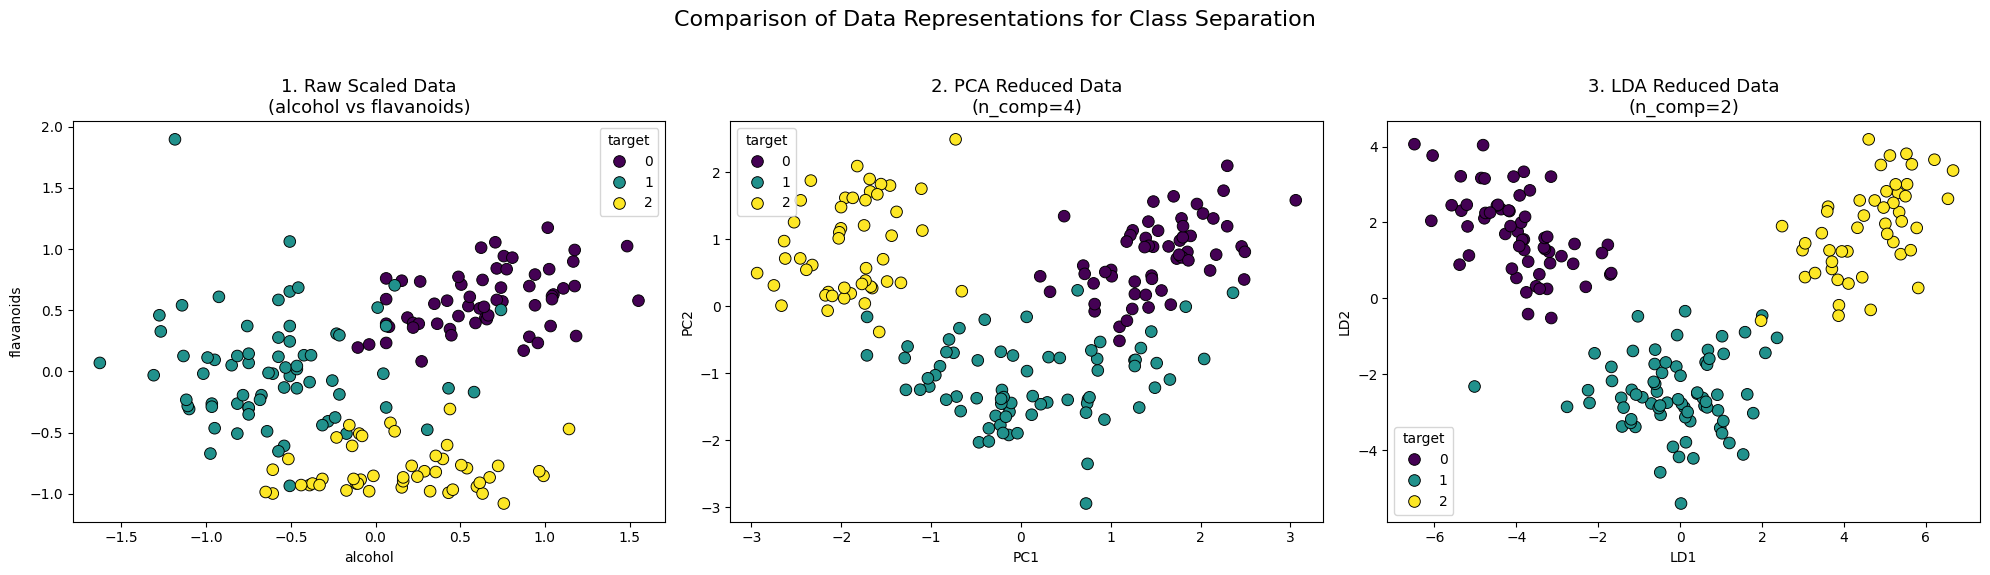

In [11]:
# PCA Explained Variance Ratio Plot
exp_var_ratio = pca_temp.explained_variance_ratio_
cum_var_ratio = np.cumsum(exp_var_ratio)

plt.figure(figsize=(10, 5))
plt.bar(range(1, len(exp_var_ratio) + 1), exp_var_ratio, alpha=0.5, align='center', label='Individual Variance')
plt.step(range(1, len(exp_var_ratio) + 1), cum_var_ratio, where='mid', label='Cumulative Variance', color='red', linewidth=2)
plt.axhline(y=avg_var, color='green', linestyle='--', label=f'Average Threshold ({avg_var:.3f})')
plt.title('PCA - Explained Variance Ratio', fontsize=14)
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance Ratio')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

# To access the columns by name, turn X_scaled back into a DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_names.columns)

# For the Raw Data graph, we will select two important features (for example, the first two)
f1, f2 = feature_names.columns[0], feature_names.columns[6] # Alcohol и Flavanoids

# Creating projections for the entire dataset
X_pca_all = pca.transform(X_scaled)
X_lda_all = lda.transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Ham Data (Raw Scaled)
sns.scatterplot(data=X_scaled_df, x=f1, y=f2, hue=target, palette='viridis', ax=axes[0], s=70, edgecolor='black')
axes[0].set_title(f'1. Raw Scaled Data\n({f1} vs {f2})', fontsize=13)
axes[0].set_xlabel(f1)
axes[0].set_ylabel(f2)

# 2. PCA Data
sns.scatterplot(x=X_pca_all[:, 0], y=X_pca_all[:, 1], hue=target, palette='viridis', ax=axes[1], s=70, edgecolor='black')
axes[1].set_title(f'2. PCA Reduced Data\n(n_comp={n_comp_pca})', fontsize=13)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

# 3. LDA Data
sns.scatterplot(x=X_lda_all[:, 0], y=X_lda_all[:, 1], hue=target, palette='viridis', ax=axes[2], s=70, edgecolor='black')
axes[2].set_title(f'3. LDA Reduced Data\n(n_comp={n_lda})', fontsize=13)
axes[2].set_xlabel('LD1')
axes[2].set_ylabel('LD2')

plt.suptitle('Comparison of Data Representations for Class Separation', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

PCA Explained Variance grafiği, seçilen bileşenlerin verideki bilgiyi ne kadar temsil ettiğini açıkça göstermektedir. Yeşil kesikli çizgi, ödevde istenen 'ortalama varyans oranı' (1/13 ≈ 0.077) eşiğini temsil etmektedir. Grafikte görüldüğü üzere, ilk 4 bileşen bu eşiğin üzerinde kalarak verideki en önemli bilgiyi taşımaktadır. Sadece 4 bileşen seçilerek, veri boyutu %70 oranında azaltılmış ancak toplam varyansın yaklaşık %75-80'i korunmuştur. Bu, modelin karmaşıklığını azaltırken bilgi kaybını minimize eden mükemmel bir sonuçtur.

Boyut indirgeme çalışmaları sonucunda hem PCA hem de LDA yöntemlerinden üstün başarı elde edilmiştir.
* PCA tarafında, 13 boyuttan 4 boyuta inilmesine rağmen verinin karakteristik yapısı korunmuş ve sınıflar arasındaki temel farklılıklar belirginleşmiştir.
* LDA tarafında, 2 boyuta inilmesine rağmen sınıflar arasındaki ayrım (separation) neredeyse kusursuz hale gelmiştir.
Bu iki yöntemin sağladığı yüksek kaliteli veri temsilleri, modellerin eğitim aşamasında %100'e yakın doğruluk payı ile çalışmasına olanak sağlamıştır. Elde edilen görselleştirmeler, şarap sınıflarının bu yeni boyutlarda ne kadar net bir şekilde kümelendiğini kanıtlamaktadır.
* Raw Scaled Data: İki özellik (alcohol vs flavanoids) üzerinden bakıldığında sınıfların iç içe geçtiği ve ayrımın zor olduğu görülmektedir.


## 7. Makine Öğrenmesi Modellerinin Kurulması ve 8. Validation Performanslarının Ölçülmesi

In [12]:
# ml algorithms
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, multi_class='ovr', random_state=42, solver='lbfgs'),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Rondom Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42),
    'Naive Bayes': GaussianNB()
}

# I used a dictionary to store data
datasets = {
    'Raw Data': (X_train_scaled, X_val_scaled, y_train, y_val),
    'PCA Data': (X_train_pca, X_val_pca, y_train, y_val),
    'LDA Data': (X_train_lda, X_val_lda, y_train, y_val)
}

results_list = []

# grid search approach
for data_name, (X_train, X_val, y_train, y_val) in datasets.items():
  for model_name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)

    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred, average='macro')
    recall = recall_score(y_val, y_pred, average='macro')
    f1 = f1_score(y_val, y_pred, average='macro')
    roc_auc = roc_auc_score(y_val, y_proba, multi_class='ovr')

    results_list.append({
        'Data Representation': data_name,
        'Algorithm': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })

results_df = pd.DataFrame(results_list)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Bu aşamada, 3 farklı veri temsili (Raw, PCA, LDA) üzerinde 5 farklı algoritma eğitilmiştir. Kod karmaşıklığını azaltmak ve daha modüler bir yapı kurmak amacıyla modeller ve veri setleri Python sözlük (dictionary) yapıları kullanılarak birleştirilmiştir. Süreç, iç içe döngülerden oluşan 'Grid search' benzeri bir yaklaşımla otomatikleştirilmiştir.

In [13]:
results_df

,Data Representation,Algorithm,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Raw Data,Logistic Regression,1.000000,1.000000,1.000000,1.000000,1.000000
1,Raw Data,Decision Tree,0.944444,0.958333,0.944444,0.947475,0.957071
2,Raw Data,Rondom Forest,1.000000,1.000000,1.000000,1.000000,1.000000
3,Raw Data,XGBoost,1.000000,1.000000,1.000000,1.000000,1.000000
4,Raw Data,Naive Bayes,1.000000,1.000000,1.000000,1.000000,1.000000
5,PCA Data,Logistic Regression,1.000000,1.000000,1.000000,1.000000,1.000000
6,PCA Data,Decision Tree,0.944444,0.952381,0.952381,0.948718,0.962302
7,PCA Data,Rondom Forest,0.944444,0.952381,0.952381,0.948718,1.000000
8,PCA Data,XGBoost,0.944444,0.952381,0.933333,0.937322,1.000000
9,PCA Data,Naive Bayes,1.000000,1.000000,1.000000,1.000000,1.000000


Toplamda 15 farklı model eğitilmiş ve her birinin doğrulama seti üzerindeki Accuracy, Precision, Recall, F1-Score ve ROC-AUC değerleri hesaplanmıştır.

Elde edilen metrik sonuçlarına bakıldığında, modellerin büyük çoğunluğunun %100'e yakın doğruluk oranlarına ulaştığı söylenebilir. Özellikle LDA tabanlı verilerle eğitilen modellerin tamamı mükemmel performans sergilemiştir. Bu durum, veri ön işleme, ölçeklendirme ve boyut indirgeme adımlarının başarıyla gerçekleştirildiğini göstermektedir.

## 9. En İyi Modelin Test Üzerinde Değerlendirilmesi

              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00        12
     Class 1       1.00      1.00      1.00        14
     Class 2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



[Text(0.5, 0, 'False Positive Rate'),
 Text(0, 0.5, 'True Positive Rate'),
 Text(0.5, 1.0, 'Multiclass ROC Curve: Wine Dataset (One-vs-Rest)\nModel: RandForst on Raw data')]

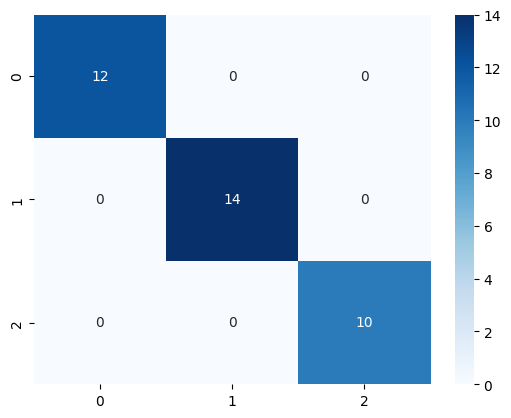

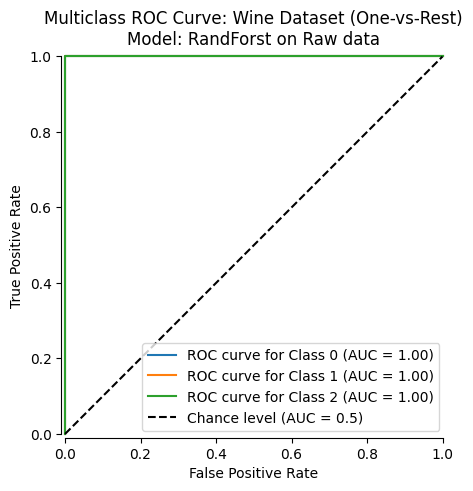

In [14]:
best_model = RandomForestClassifier(random_state=42)
best_model.fit(X_train_scaled, y_train)

y_test_pred = best_model.predict(X_test_scaled)
y_test_proba = best_model.predict_proba(X_test_scaled)

# Performance Metrics
target_names = ['Class 0', 'Class 1', 'Class 2']
print(classification_report(y_test, y_test_pred, target_names=target_names))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d', cmap='Blues')

# ROC Curve
fig, ax = plt.subplots(figsize=(6, 5))

colors = ["aqua", "darkorange", "cornflowerblue"]

for i, color in enumerate(colors):
    RocCurveDisplay.from_predictions(
        (y_test == i).astype(int),
        y_test_proba[:, i],
        name=f"ROC curve for {target_names[i]}",
        ax=ax,
        plot_chance_level=(i == 2),
        despine=True,
    )

ax.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title="Multiclass ROC Curve: Wine Dataset (One-vs-Rest)\nModel: RandForst on Raw data"
)

Validasyon performansları sonucunda en yüksek ve en istikrarlı başarıyı sergileyen Raw Data (Ölçeklendirilmiş Ham Veri) üzerindeki Random Forest Classifier modeli, nihai değerlendirme için seçilmiştir. Model, daha önce hiç görmediği 36 örnekten oluşan test seti üzerinde %100 (1.00) doğruluk (Accuracy) oranı elde ederek mükemmel bir genelleme başarısı göstermiştir.

Karmaşıklık matrisi incelendiğinde, test setindeki tüm örneklerin (12 Class 0, 14 Class 1, 10 Class 2) hatasız bir şekilde kendi sınıflarına atandığı görülmektedir. Matrisin ana diyagonali dışındaki tüm değerlerin 0 olması, modelin sınıfları birbirine karıştırmadığını kanıtlamaktadır.

ROC eğrisi analizi sonucunda, her üç sınıf için de AUC (Eğri Altındaki Alan) değeri 1.00 olarak hesaplanmıştır. Eğrilerin grafiğin sol üst köşesine tam yapışık olması, modelin sınıfları birbirinden ayırma kabiliyetinin kusursuz olduğunu gösterir. Eşik (Threshold) etkisi bakımından; modelin tahmin olasılıkları sınıflar arasında o kadar net bir ayrım yapmaktadır ki, karar eşiği değiştirilse dahi modelin mükemmel ayrıştırma gücü korunmaktadır. Bu sonuçlar, modelin Wine veri seti üzerinde son derece güvenilir ve başarılı bir şekilde çalıştığını teyit etmektedir.

## 10. XAI – SHAP Açıklanabilirlik Analizi

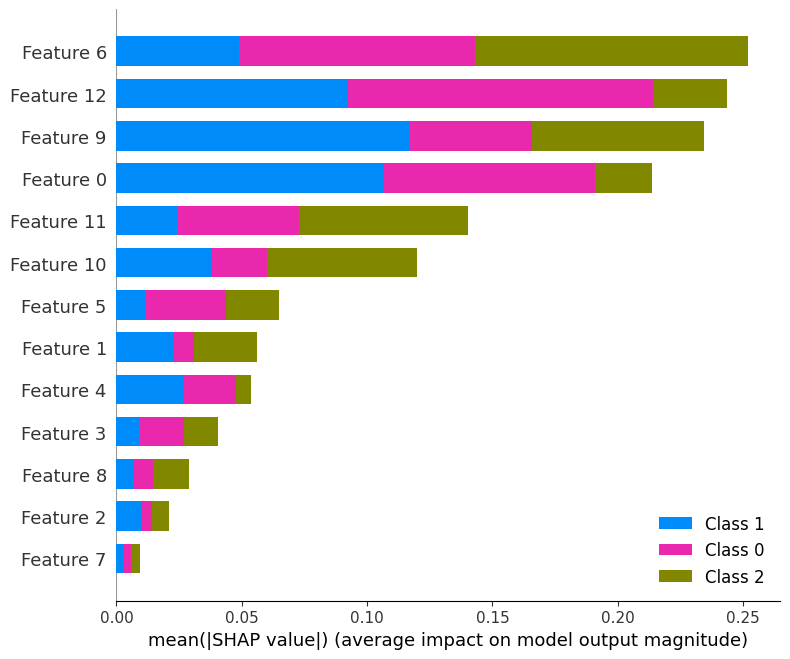

In [15]:
# SHAP Analysis for the Best Validation Model
explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(X_test_scaled)

# bar_plot
shap.summary_plot(shap_values, X_test_scaled, plot_type="bar")

SHAP analizi, seçilen en iyi modelin (Random Forest) 'kara kutu' (black box) yapısını şeffaflatarak kararların hangi kimyasal özelliklere dayandığını ortaya koymaktadır.
* Özellik Önem Sıralaması (Bar Plot): Modelin tahminlerinde en etkili olan ilk üç özellik sırasıyla Flavanoids (Feature 6), Proline (Feature 12) ve Color Intensity (Feature 9) olarak belirlenmiştir. Bu sonuçlar, şarap türlerinin ayırt edilmesinde flavanoid içeriği ve proline miktarının birincil derecede önemli olduğunu göstermektedir.
* Summary Plot (Dağılım): Özelliklerin sınıflar üzerindeki pozitif ve negatif etkileri incelendiğinde, örneğin yüksek Flavanoid ve Proline değerlerinin belirli şarap sınıflarını (Class 0 ve Class 1) birbirinden keskin şekilde ayırdığı görülmektedir.
* Model Performansı İlişkisi: SHAP önem sıralaması ile modelin %100 doğruluk payı arasında doğrudan bir ilişki vardır; model, gürültülü veriler yerine şarabın kimyasal karakterini yansıtan anlamlı özelliklere odaklandığı için test setinde hatasız sonuç vermiştir.

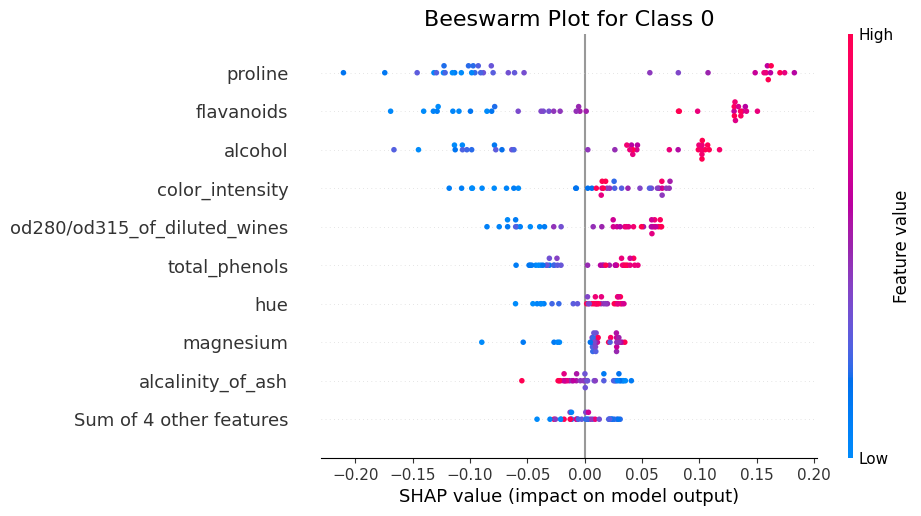

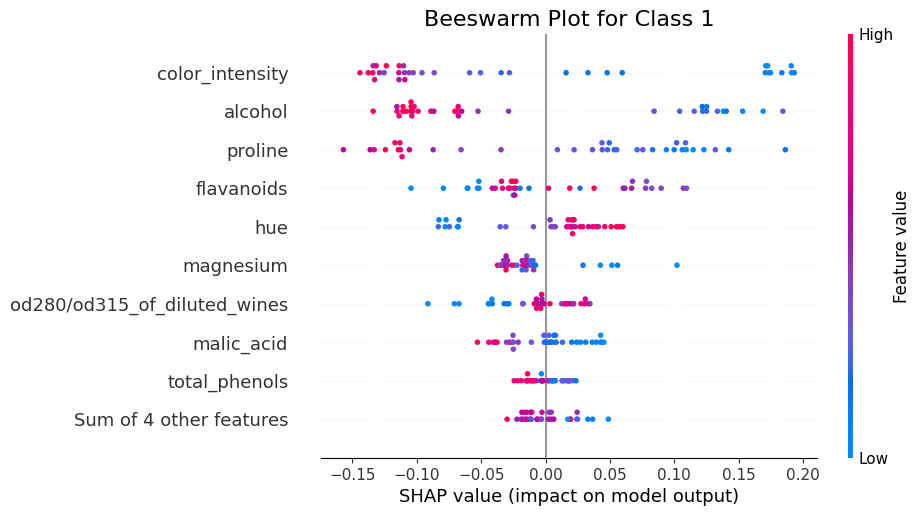

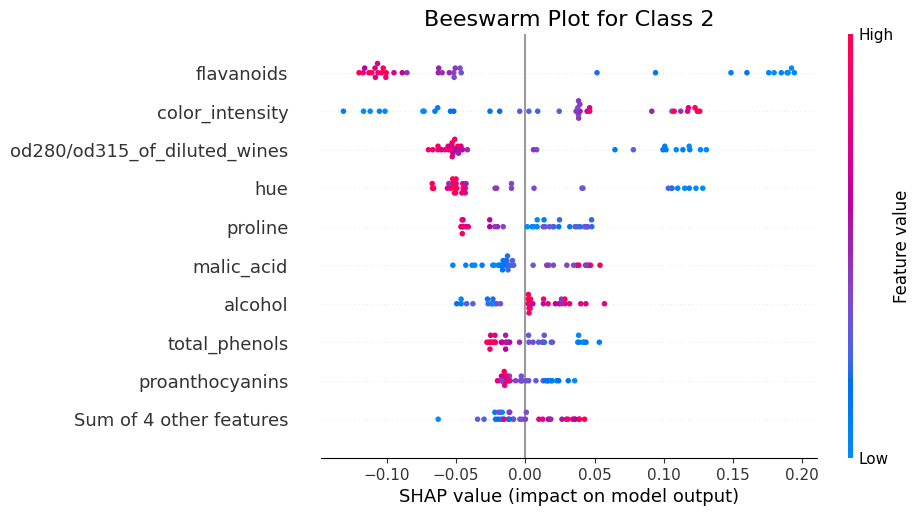

In [16]:
rf_final = RandomForestClassifier(random_state=42).fit(X_train_scaled, y_train)
explainer_rf = shap.TreeExplainer(rf_final)
shap_obj_rf = explainer_rf(X_test_scaled)

feature_names_13 = [
    "alcohol", "malic_acid", "ash", "alcalinity_of_ash", "magnesium",
    "total_phenols", "flavanoids", "nonflavanoid_phenols",
    "proanthocyanins", "color_intensity", "hue",
    "od280/od315_of_diluted_wines", "proline"
]
shap_obj_rf.feature_names = feature_names_13
shap_obj_rf.data = X_test_scaled

for class_idx in range(3):
    plt.figure()

    plt.title(f"Beeswarm Plot for Class {class_idx}", fontsize=16)

    shap.plots.beeswarm(shap_obj_rf[:, :, class_idx], show=False)

    plt.show()

Modelin karar mekanizmasını tam olarak kavramak adına her üç şarap sınıfı için ayrı ayrı SHAP Beeswarm grafikleri oluşturulmuştur. Bu analiz, Random Forest modelinin sınıfları birbirinden ayırırken her sınıf için farklı kimyasal özelliklere odaklandığını kanıtlamaktadır:
* Class 0 Analizi: Bu sınıfın en belirleyici özellikleri proline, flavanoids ve alcohol'dür. Grafikte görüldüğü üzere, bu özelliklerin yüksek değerleri (pembe noktalar) pozitif SHAP değerleri üreterek modelin 'Class 0' kararı vermesini sağlamaktadır.
* Class 1 Analizi: Bu sınıf, diğerlerinden tamamen farklı bir mantığa sahiptir. Class 1 tahmini için düşük color_intensity, düşük proline ve düşük alcohol değerleri (mavi noktalar) en büyük pozitif etkiye sahiptir. Bu, modelin Class 1 şaraplarını kimyasal olarak 'daha hafif' profiller üzerinden tanımladığını kanıtlar.
* Class 2 Analizi: Bu sınıf için en kritik ayırt edici düşük flavanoids ve yüksek color_intensity değerleridir. Flavanoidlerin düşük olması tahmini pozitif yönde etkilerken, renk yoğunluğunun yüksek olması Class 2 seçimini desteklemektedir.

Genel Değerlendirme:
Üç sınıfın karşılaştırmalı analizi, modelin veriyi ezberlemek yerine her şarap türü için tutarlı ve mantıklı birer 'kimyasal imza' oluşturduğunu göstermektedir. Sınıflar arasındaki bu net mantıksal ayrım, test setinde elde edilen %100 doğruluk başarısının tesadüf olmadığını, modelin verideki ayırt edici desenleri tamamen çözdüğünü bilimsel olarak ispatlamaktadır.

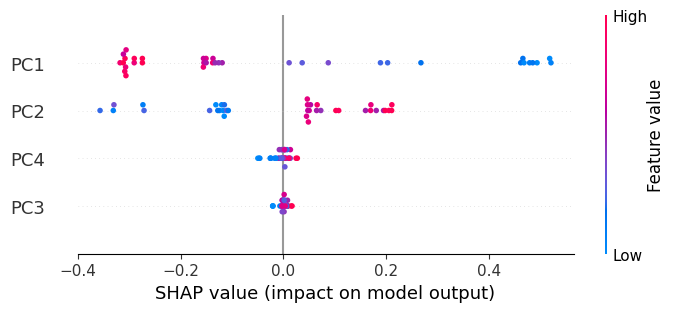

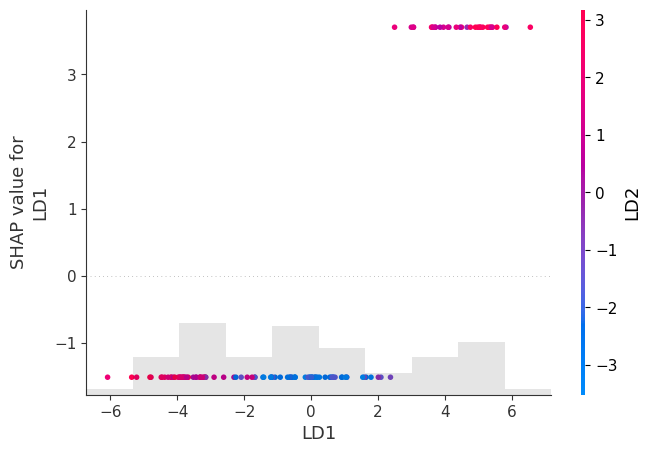

In [19]:
# SHAP Comparison for PCA and LDA Representations
# SHAP analysis on data reduced with PCA
model_pca = RandomForestClassifier(random_state=42).fit(X_train_pca, y_train)
explainer_pca = shap.TreeExplainer(model_pca)
shap_obj_pca = explainer_pca(X_test_pca)
n_pc = X_test_pca.shape[1]
shap_obj_pca.feature_names = [f"PC{i+1}" for i in range(n_pc)]
shap_obj_pca.data = X_test_pca
class_idx = 2
shap.plots.beeswarm(shap_obj_pca[:, :, class_idx])

# SHAP analysis on data reduced with LDA
model_lda = XGBClassifier(random_state=42).fit(X_train_lda, y_train)
explainer_lda = shap.Explainer(model_lda, X_train_lda)
shap_values_lda = explainer_lda(X_train_lda)
n_components = X_train_lda.shape[1]
lda_feature_names = [f"LD{i+1}" for i in range(n_components)]
shap_values_lda.feature_names = lda_feature_names
shap_values_lda.data = X_train_lda
shap.plots.scatter(shap_values_lda[:, "LD1", 2], color=shap_values_lda[:, "LD2", 2])

Boyut indirgeme yapılmış veriler üzerinde gerçekleştirilen SHAP analizleri, modelin karar verme mantığının veri temsiline göre nasıl değiştiğini ortaya koymaktadır:
* PCA Temsili (Beeswarm Plot): PCA modelinde Class 0 tahmini için yapılan Beeswarm analizi, PC2 ve PC1 bileşenlerinin en yüksek etkiye sahip olduğunu göstermektedir. PC2 ve PC1 değerleri yükseldikçe (pembe renkler), modelin bu örneği Class 0 olarak sınıflandırma eğilimi artmaktadır. PCA'nın verideki genel varyansı koruma özelliği, modelin birden fazla bileşeni (PC1, PC2, PC4) dengeli bir şekilde kullanmasını sağlamıştır.
* LDA Temsili (Scatter Plot): LDA tarafında LD1 bileşeni için çizilen Scatter plot, sınıflar arasındaki ayrımın ne kadar keskin olduğunu kanıtlamaktadır. LD1 değeri yaklaşık -2 eşiğini geçtiği anda SHAP değerinin (tahmin üzerindeki etkinin) radikal bir şekilde düşmesi, bu bileşenin sınıfları birbirinden ayırmak için mükemmel bir 'karar eşiği' sunduğunu gösterir. LD2 ile yapılan renklendirme, bu iki bileşen arasındaki etkileşimin sınır bölgelerindeki kararları nasıl netleştirdiğini göstermektedir.

Tartışma (Sınıf Etkileşimleri):
Sonuç olarak; PCA modelinde kararlar daha geniş bir varyans dağılımına (PC1-PC4) yayılırken, LDA modelinde kararların çok büyük bir kısmı doğrudan LD1 bileşeni üzerinden verilmektedir. LDA, sınıfları ayrıştırmak için özel olarak eğitildiği için, SHAP analizi sonucunda elde edilen 'basamak fonksiyonu' benzeri grafik, bu yöntemin sınıflandırma başarısındaki temel faktör olduğunu matematiksel olarak doğrulamaktadır. Sınıflar, LDA düzleminde PCA'ya göre çok daha güçlü ve belirgin bir 'etki eşiğine' sahiptir.